In [1]:
import pandas as pd

traffic_df = pd.read_excel(r"C:\Users\dknom\Documents\school\CE5620_traffic_analysis\hw\homework2.xlsx", sheet_name="Report Data")

traffic_df = traffic_df.rename(columns={
    "3412011 Lane 1 Speed - Not Used in Calculations": "lane1_speed", 
    "3412011 Lane 2 Speed - Not Used in Calculations": "lane2_speed",
    "3412011 Lane 3 Speed - Not Used in Calculations": "lane3_speed",
    "3412011 Lane 1 Flow": "lane1_flow",
    "3412011 Lane 2 Flow": "lane2_flow",
    "3412011 Lane 3 Flow": "lane3_flow",
    })

# Cap speeds at 100 mph
traffic_df.loc[traffic_df['lane1_speed'] > 100, 'lane1_speed'] = 100.0
traffic_df.loc[traffic_df['lane3_speed'] > 100, 'lane3_speed'] = 100.0

# Flow is veh / 30 sec, so (veh * 3600 sec/hr) / 30 sec = veh*120 to get veh / hr
traffic_df['lane1_flow'] = traffic_df['lane1_flow'] * 120
traffic_df['lane3_flow'] = traffic_df['lane3_flow'] * 120

# Cap flow at 2400 veh/hr
traffic_df.loc[traffic_df['lane1_flow'] > 2400, 'lane1_flow'] = 2400
traffic_df.loc[traffic_df['lane3_flow'] > 2400, 'lane3_flow'] = 2400


In [2]:
import numpy as np
# Flow is veh / 30 sec, so (veh * 3600 sec/hr) / 30 sec to get veh / hr
traffic_df["lane1_density"] = (traffic_df["lane1_flow"]) / traffic_df['lane1_speed']
traffic_df["lane3_density"] = (traffic_df["lane3_flow"]) / traffic_df['lane3_speed']
traffic_df["lane1_ln_density"] = np.log(traffic_df['lane1_density'])
traffic_df["lane3_ln_density"] = np.log(traffic_df['lane3_density'])
traffic_df["lane1_density_sq"] = traffic_df['lane1_density'] ** 2
traffic_df["lane3_density_sq"] = traffic_df['lane3_density'] ** 2
traffic_df["lane1_ln_speed"] = np.log(traffic_df['lane1_speed'])
traffic_df["lane3_ln_speed"] = np.log(traffic_df['lane3_speed'])
traffic_df[[
    "lane1_density",
    "lane3_density",
    "lane1_ln_density",
    "lane3_ln_density",
    "lane1_density_sq",
    "lane3_density_sq",
    "lane1_ln_speed",
    "lane3_ln_speed",
    "lane1_speed",
    "lane1_flow",
    "lane3_speed",
    "lane3_flow",
    ]].describe(include='all')

,lane1_density,lane3_density,lane1_ln_density,lane3_ln_density,lane1_density_sq,lane3_density_sq,lane1_ln_speed,lane3_ln_speed,lane1_speed,lane1_flow,lane3_speed,lane3_flow
count,2314.000000,2553.000000,2314.000000,2553.000000,2314.000000,2553.000000,2314.000000,2553.000000,2314.000000,2879.000000,2553.00000,2879.000000
mean,11.960639,10.048105,2.183385,1.997823,208.439103,189.267170,4.298835,3.960193,73.754538,695.074679,54.62358,420.937826
std,8.087675,9.398795,0.860686,0.805454,253.934170,1201.803127,0.062809,0.311478,4.437907,608.848398,13.68206,299.566671
min,1.200000,1.200000,0.182322,0.182322,1.440000,1.440000,3.583519,0.693147,36.000000,0.000000,2.00000,0.000000
25%,4.931507,3.934426,1.595645,1.369765,24.319760,15.479710,4.276666,3.828641,72.000000,120.000000,46.00000,240.000000
50%,11.052632,8.000000,2.402669,2.079442,122.160665,64.000000,4.304065,4.077537,74.000000,600.000000,59.00000,360.000000
75%,16.894806,13.333333,2.827006,2.590267,285.434612,177.777778,4.330733,4.143135,76.000000,1080.000000,63.00000,600.000000
max,40.000000,240.000000,3.688879,5.480639,1600.000000,57600.000000,4.605170,4.605170,100.000000,2400.000000,100.00000,1680.000000


In [3]:
traffic_df = traffic_df[traffic_df['lane3_density'] < 240]

traffic_df[[
    "lane1_density",
    "lane3_density",
    "lane1_ln_density",
    "lane3_ln_density",
    "lane1_density_sq",
    "lane3_density_sq",
    "lane1_ln_speed",
    "lane3_ln_speed",
    "lane1_speed",
    "lane1_flow",
    "lane3_speed",
    "lane3_flow",
    ]].describe(include='all')

,lane1_density,lane3_density,lane1_ln_density,lane3_ln_density,lane1_density_sq,lane3_density_sq,lane1_ln_speed,lane3_ln_speed,lane1_speed,lane1_flow,lane3_speed,lane3_flow
count,2205.000000,2552.000000,2205.000000,2552.000000,2205.000000,2552.000000,2205.000000,2552.000000,2205.000000,2552.000000,2552.000000,2552.000000
mean,12.309897,9.957999,2.231576,1.996459,216.263689,166.770802,4.297294,3.961473,73.640363,768.479624,54.644201,471.159875
std,8.047328,8.224085,0.833891,0.802654,256.419961,390.322121,0.062718,0.304748,4.413404,600.871868,13.645006,279.973515
min,1.200000,1.200000,0.182322,0.182322,1.440000,1.440000,3.583519,1.386294,36.000000,0.000000,4.000000,120.000000
25%,6.233766,3.934426,1.829981,1.369765,38.859841,15.479710,4.276666,3.828641,72.000000,240.000000,46.000000,240.000000
50%,11.200000,8.000000,2.415914,2.079442,125.440000,64.000000,4.304065,4.077537,74.000000,720.000000,59.000000,480.000000
75%,17.600000,13.333333,2.867899,2.590267,309.760000,177.777778,4.330733,4.143135,76.000000,1200.000000,63.000000,600.000000
max,40.000000,96.000000,3.688879,4.564348,1600.000000,9216.000000,4.605170,4.605170,100.000000,2400.000000,100.000000,1680.000000


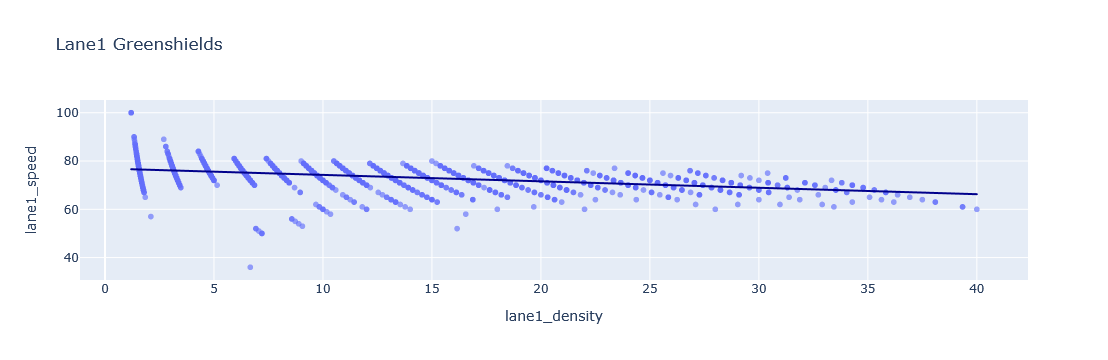

In [4]:
import plotly.express as px 

greenshields_fig1 = px.scatter(
    traffic_df,
    x="lane1_density",
    y="lane1_speed",
    opacity=0.65,
    trendline="ols",
    trendline_color_override="darkblue",
    title="Lane1 Greenshields"
)

greenshields_fig1.show()



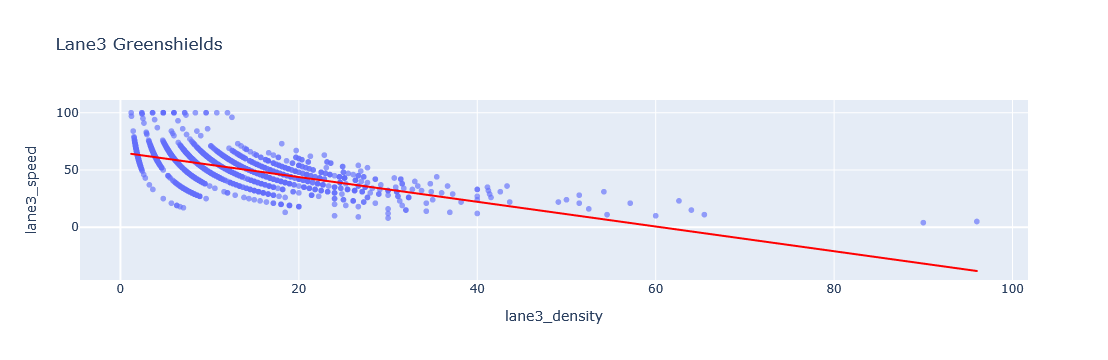

In [5]:
greenshields_fig3 = px.scatter(
    traffic_df,
    x="lane3_density",
    y="lane3_speed",
    opacity=0.65,
    trendline="ols",
    trendline_color_override="red",
    title="Lane3 Greenshields"
)

greenshields_fig3.show()


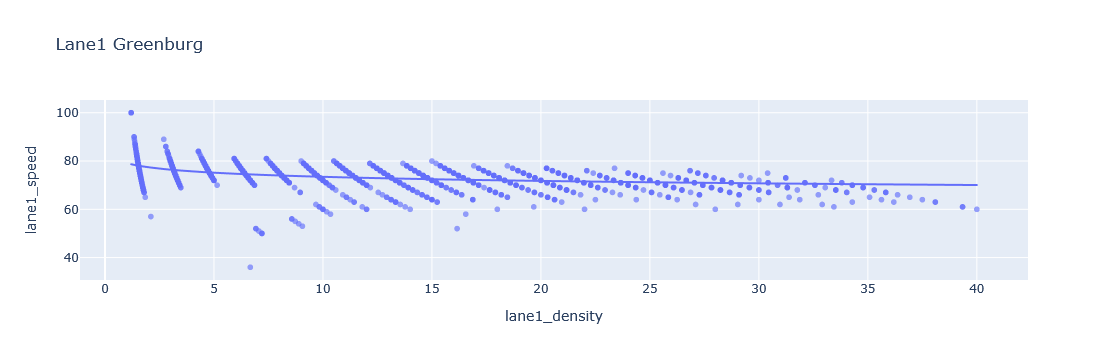

In [6]:
greenburg_fig1 = px.scatter(
    traffic_df,
    x="lane1_density",
    y="lane1_speed",
    opacity=0.65,
    trendline="ols",
    trendline_options=dict(log_x=True),
    title="Lane1 Greenburg"
)

greenburg_fig1.show()


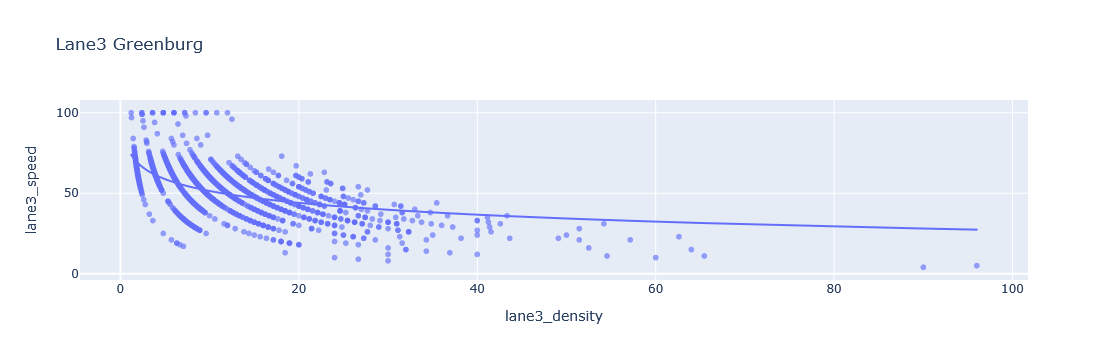

In [7]:
greenburg_fig3 = px.scatter(
    traffic_df,
    x="lane3_density",
    y="lane3_speed",
    opacity=0.65,
    trendline="ols",
    trendline_options=dict(log_x=True),
    title="Lane3 Greenburg"
)

greenburg_fig3.show()


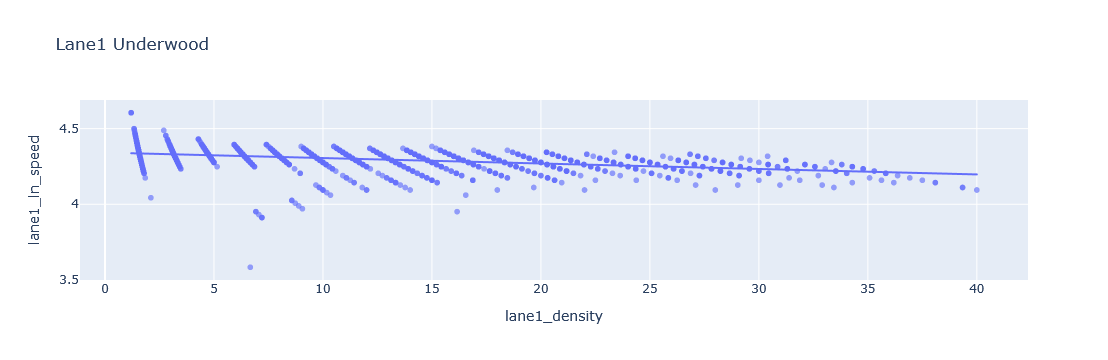

In [8]:
underwood_fig1 = px.scatter(
    traffic_df,
    x="lane1_density",
    y="lane1_ln_speed",
    opacity=0.65,
    trendline="ols",
    title="Lane1 Underwood"
)

underwood_fig1.show()


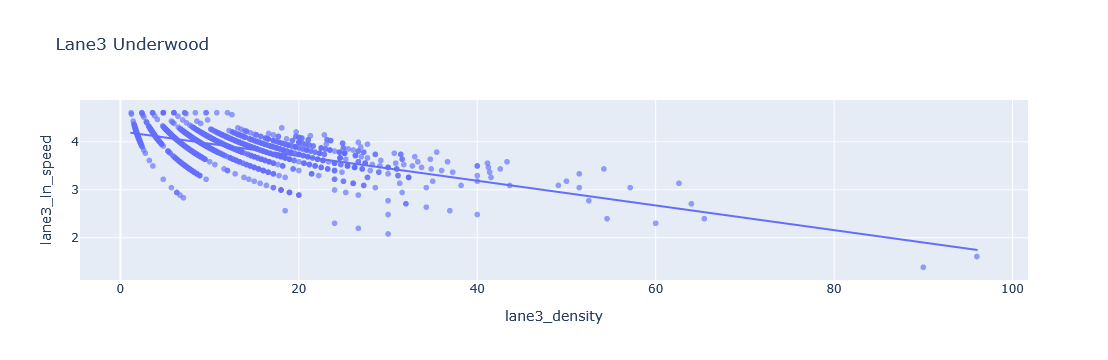

In [9]:
underwood_fig3 = px.scatter(
    traffic_df,
    x="lane3_density",
    y="lane3_ln_speed",
    opacity=0.65,
    trendline="ols",
    title="Lane3 Underwood"
)

underwood_fig3.show()


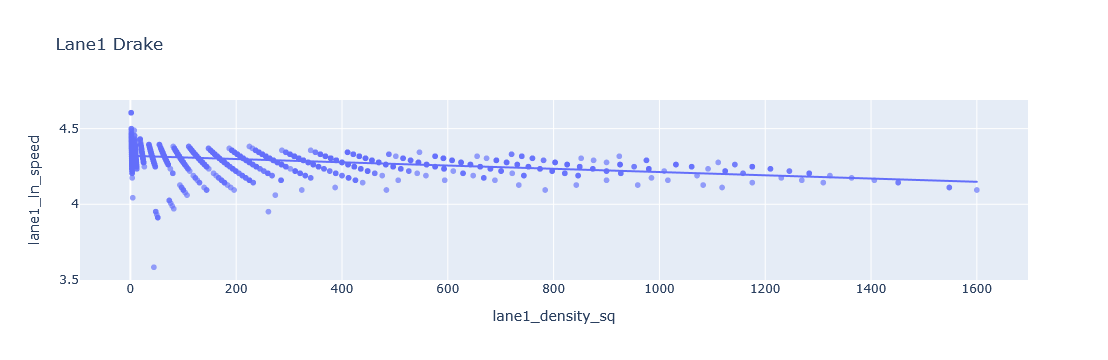

In [10]:
drake_fig1 = px.scatter(
    traffic_df,
    x="lane1_density_sq",
    y="lane1_ln_speed",
    opacity=0.65,
    trendline="ols",
    title="Lane1 Drake"
)

drake_fig1.show()


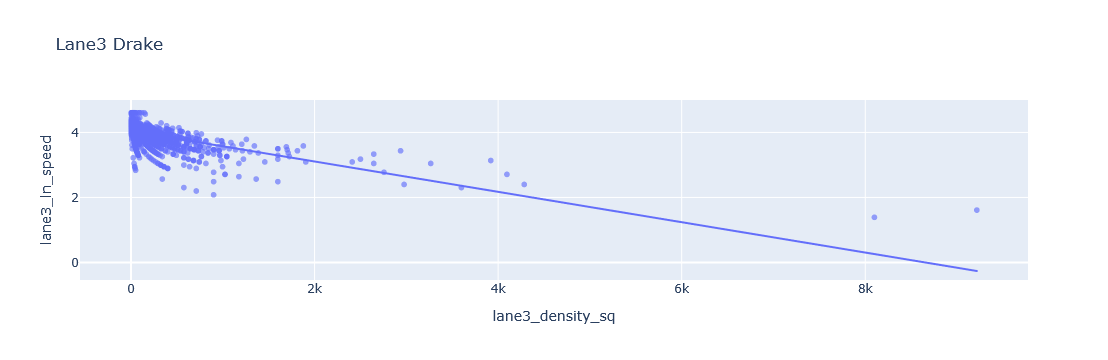

In [11]:
drake_fig3 = px.scatter(
    traffic_df,
    x="lane3_density_sq",
    y="lane3_ln_speed",
    opacity=0.65,
    trendline="ols",
    title="Lane3 Drake"
)

drake_fig3.show()


In [12]:
import numpy as np 

rows = ['Greenshields', 'Greenburg', 'Underwood', 'Drake']
results_df = pd.DataFrame(
    {
        "lane1_Vf": np.zeros(len(rows), dtype=float),
        "lane1_Vc": np.zeros(len(rows), dtype=float),
        "lane1_Kj": np.zeros(len(rows), dtype=float),
        "lane1_Kc": np.zeros(len(rows), dtype=float),
        "lane1_Qmax": np.zeros(len(rows), dtype=float),
        "lane1_Rsq": np.zeros(len(rows), dtype=float),
        "lane3_Vf": np.zeros(len(rows), dtype=float),
        "lane3_Vc": np.zeros(len(rows), dtype=float),
        "lane3_Kj": np.zeros(len(rows), dtype=float),
        "lane3_Qmax": np.zeros(len(rows), dtype=float),
        "lane3_Rsq": np.zeros(len(rows), dtype=float),
    }, index=rows)

results_df

,lane1_Vf,lane1_Vc,lane1_Kj,lane1_Kc,lane1_Qmax,lane1_Rsq,lane3_Vf,lane3_Vc,lane3_Kj,lane3_Qmax,lane3_Rsq
Greenshields,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Greenburg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Underwood,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Drake,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
greenshields_results1 = px.get_trendline_results(greenshields_fig1).iloc[0]['px_fit_results']
greenshields_Vf1, greenshields_intercept1 = greenshields_results1.params
greenshields_Kj1 = -greenshields_Vf1 / greenshields_intercept1

greenshields_results3 = px.get_trendline_results(greenshields_fig3).iloc[0]['px_fit_results']
greenshields_Vf3, x3 = greenshields_results3.params
greenshields_Kj3 = -greenshields_Vf3 / x3

results_df.loc['Greenshields',"lane1_Vf"] = greenshields_Vf1
results_df.loc['Greenshields',"lane1_Vc"] = greenshields_Vf1 / 2
results_df.loc['Greenshields',"lane1_Kj"] = greenshields_Kj1
results_df.loc['Greenshields',"lane1_Kc"] = greenshields_Kj1 / 2
results_df.loc['Greenshields',"lane1_Qmax"] = greenshields_Kj1 * greenshields_Vf1 / 4
results_df.loc['Greenshields',"lane1_Rsq"] = greenshields_results1.rsquared
results_df.loc['Greenshields',"lane3_Vf"] = greenshields_Vf3
results_df.loc['Greenshields',"lane3_Vc"] = greenshields_Vf3 / 2
results_df.loc['Greenshields',"lane3_Kj"] = greenshields_Kj3
results_df.loc['Greenshields',"lane3_Kc"] = greenshields_Kj3 / 2
results_df.loc['Greenshields',"lane3_Qmax"] = greenshields_Kj3 * greenshields_Vf3 / 4
results_df.loc['Greenshields',"lane3_Rsq"] = greenshields_results3.rsquared

results_df

,lane1_Vf,lane1_Vc,lane1_Kj,lane1_Kc,lane1_Qmax,lane1_Rsq,lane3_Vf,lane3_Vc,lane3_Kj,lane3_Qmax,lane3_Rsq,lane3_Kc
Greenshields,76.921528,38.460764,288.585313,144.292657,5549.605826,0.236213,65.394305,32.697152,60.575823,990.328458,0.423359,30.287912
Greenburg,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
Underwood,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
Drake,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN


In [14]:
import math 
greenburg_results1 = px.get_trendline_results(greenburg_fig1).iloc[0]['px_fit_results']
greenburg_intercept1, greenburg_constant1 = greenburg_results1.params
greenburg_Vc1 = -greenburg_constant1 / math.log(10)
greenburg_Kj1 = math.exp(greenburg_intercept1/greenburg_Vc1)

greenburg_results3 = px.get_trendline_results(greenburg_fig3).iloc[0]['px_fit_results']
greenburg_intercept3, greenburg_constant3 = greenburg_results3.params
greenburg_Vc3 = -greenburg_constant3 / math.log(10)
greenburg_Kj3 = math.exp(greenburg_intercept3/greenburg_Vc3)

results_df.loc['Greenburg',"lane1_Vf"] = np.nan
results_df.loc['Greenburg',"lane1_Vc"] = greenburg_Vc1
results_df.loc['Greenburg',"lane1_Kj"] = greenburg_Kj1
results_df.loc['Greenburg',"lane1_Kc"] = greenburg_Kj1 / math.e
results_df.loc['Greenburg',"lane1_Qmax"] = greenburg_Kj1 * greenburg_Vc1 / math.e
results_df.loc['Greenburg',"lane1_Rsq"] = greenburg_results1.rsquared
results_df.loc['Greenburg',"lane3_Vf"] = np.nan
results_df.loc['Greenburg',"lane3_Vc"] = greenburg_Vc3
results_df.loc['Greenburg',"lane3_Kj"] = greenburg_Kj3
results_df.loc['Greenburg',"lane3_Kc"] = greenburg_Kj3 / math.e
results_df.loc['Greenburg',"lane3_Qmax"] = greenburg_Kj3 * greenburg_Vc3 / math.e
results_df.loc['Greenburg',"lane3_Rsq"] = greenburg_results3.rsquared

results_df


,lane1_Vf,lane1_Vc,lane1_Kj,lane1_Kc,lane1_Qmax,lane1_Rsq,lane3_Vf,lane3_Vc,lane3_Kj,lane3_Qmax,lane3_Rsq,lane3_Kc
Greenshields,76.921528,38.460764,2.885853e+02,1.442927e+02,5.549606e+03,0.236213,65.394305,32.697152,60.575823,990.328458,0.423359,30.287912
Greenburg,NaN,2.459185,9.421492e+13,3.465973e+13,8.523471e+13,0.215900,NaN,10.621845,1262.652254,4933.887447,0.390400,464.503806
Underwood,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
Drake,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN


In [15]:
underwood_results3 = px.get_trendline_results(underwood_fig3).iloc[0]['px_fit_results']
underwood_intercept3, underwood_constant3 = underwood_results3.params
underwood_Vf3 = math.exp(underwood_intercept3)
underwood_Kc3 = -1 / underwood_constant3

underwood_results1 = px.get_trendline_results(underwood_fig1).iloc[0]['px_fit_results']
underwood_intercept1, underwood_constant1 = underwood_results1.params
underwood_Vf1 = math.exp(underwood_intercept1)
underwood_Kc1 = -1 / underwood_constant1

results_df.loc['Underwood',"lane1_Vf"] = underwood_Vf1
results_df.loc['Underwood',"lane1_Vc"] = underwood_Vf1 / math.e
results_df.loc['Underwood',"lane1_Kj"] = math.nan
results_df.loc['Underwood',"lane1_Kc"] = underwood_Kc1
results_df.loc['Underwood',"lane1_Qmax"] = underwood_Kc1 * underwood_Vf1 / math.e
results_df.loc['Underwood',"lane1_Rsq"] = underwood_results1.rsquared
results_df.loc['Underwood',"lane3_Vf"] = underwood_Vf3
results_df.loc['Underwood',"lane3_Vc"] = underwood_Vf3 / math.e
results_df.loc['Underwood',"lane3_Kj"] = math.nan
results_df.loc['Underwood',"lane3_Kc"] = underwood_Kc3
results_df.loc['Underwood',"lane3_Qmax"] = underwood_Kc3 * underwood_Vf3 / math.e
results_df.loc['Underwood',"lane3_Rsq"] = underwood_results3.rsquared

results_df


,lane1_Vf,lane1_Vc,lane1_Kj,lane1_Kc,lane1_Qmax,lane1_Rsq,lane3_Vf,lane3_Vc,lane3_Kj,lane3_Qmax,lane3_Rsq,lane3_Kc
Greenshields,76.921528,38.460764,2.885853e+02,1.442927e+02,5.549606e+03,0.236213,65.394305,32.697152,60.575823,990.328458,0.423359,30.287912
Greenburg,NaN,2.459185,9.421492e+13,3.465973e+13,8.523471e+13,0.215900,NaN,10.621845,1262.652254,4933.887447,0.390400,464.503806
Underwood,76.842078,28.268621,NaN,2.768874e+02,7.827224e+03,0.214737,67.878027,24.970931,NaN,970.422649,0.482217,38.862094
Drake,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN


In [16]:
drake_results3 = px.get_trendline_results(drake_fig3).iloc[0]['px_fit_results']
drake_intercept3, drake_constant3 = drake_results3.params
drake_Vf3 = math.exp(drake_intercept3)
drake_Kc3 = math.sqrt(-1 / (2 * drake_constant3))

drake_results1 = px.get_trendline_results(drake_fig1).iloc[0]['px_fit_results']
drake_intercept1, drake_constant1 = drake_results1.params
drake_Vf1 = math.exp(drake_intercept1)
drake_Kc1 = math.sqrt(-1 / (2 * drake_constant1))

results_df.loc['Drake',"lane1_Vf"] = drake_Vf1
results_df.loc['Drake',"lane1_Vc"] = drake_Vf1 / math.sqrt(math.e)
results_df.loc['Drake',"lane1_Kj"] = math.nan
results_df.loc['Drake',"lane1_Kc"] = drake_Kc1
results_df.loc['Drake',"lane1_Qmax"] = drake_Kc1 * drake_Vf1 / math.sqrt(math.e)
results_df.loc['Drake',"lane1_Rsq"] = drake_results1.rsquared
results_df.loc['Drake',"lane3_Vf"] = drake_Vf3
results_df.loc['Drake',"lane3_Vc"] = drake_Vf3 / math.sqrt(math.e)
results_df.loc['Drake',"lane3_Kj"] = math.nan
results_df.loc['Drake',"lane3_Kc"] = drake_Kc3
results_df.loc['Drake',"lane3_Qmax"] = drake_Kc3 * drake_Vf3 / math.sqrt(math.e)
results_df.loc['Drake',"lane3_Rsq"] = drake_results3.rsquared

results_df


,lane1_Vf,lane1_Vc,lane1_Kj,lane1_Kc,lane1_Qmax,lane1_Rsq,lane3_Vf,lane3_Vc,lane3_Kj,lane3_Qmax,lane3_Rsq,lane3_Kc
Greenshields,76.921528,38.460764,2.885853e+02,1.442927e+02,5.549606e+03,0.236213,65.394305,32.697152,60.575823,990.328458,0.423359,30.287912
Greenburg,NaN,2.459185,9.421492e+13,3.465973e+13,8.523471e+13,0.215900,NaN,10.621845,1262.652254,4933.887447,0.390400,464.503806
Underwood,76.842078,28.268621,NaN,2.768874e+02,7.827224e+03,0.214737,67.878027,24.970931,NaN,970.422649,0.482217,38.862094
Drake,75.229601,45.629060,NaN,6.819621e+01,3.111729e+03,0.193203,56.789898,34.444814,NaN,1127.043500,0.357799,32.720267
